<a href="https://colab.research.google.com/github/Matheusbcy/-Data-Science-IA-/blob/main/NLP%20-%20Natural%20Language%20Processing/Tokenizer%20with%20BERT/Processamento_de_Linguagem_Natural_com_BERT_e_Python.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Etapa 1: Importações das biblitoecas**

In [2]:
import numpy as np
import math
import re
import pandas as pd
from bs4 import BeautifulSoup
import random
import seaborn as sns
import matplotlib.pyplot as plt
from google.colab import drive

In [ ]:
!pip install transformers tensorflow

In [3]:
from transformers import TFBertModel, BertTokenizer
import tensorflow as tf

In [4]:
!pip install sentencepiece

In [5]:
%tensorflow_version 2.x

Colab only includes TensorFlow 2.x; %tensorflow_version has no effect.


In [47]:
from tensorflow.keras import layers

# **Etapa 2: Pré-processamento**

In [6]:
drive.mount('/content/drive')

Mounted at /content/drive


In [7]:
cols = ["sentiment", "id", "date", "query", "user", "text"]

In [8]:
data = pd.read_csv("/content/drive/MyDrive/NLP - Processamento de Linguagem Natural/training.1600000.processed.noemoticon.csv", header = None,
                   names = cols,
                   engine = "python",
                   encoding = "latin1")

In [9]:
data.head()

,sentiment,id,date,query,user,text
0,0,1467810369,Mon Apr 06 22:19:45 PDT 2009,NO_QUERY,_TheSpecialOne_,"@switchfoot http://twitpic.com/2y1zl - Awww, t..."
1,0,1467810672,Mon Apr 06 22:19:49 PDT 2009,NO_QUERY,scotthamilton,is upset that he can't update his Facebook by ...
2,0,1467810917,Mon Apr 06 22:19:53 PDT 2009,NO_QUERY,mattycus,@Kenichan I dived many times for the ball. Man...
3,0,1467811184,Mon Apr 06 22:19:57 PDT 2009,NO_QUERY,ElleCTF,my whole body feels itchy and like its on fire
4,0,1467811193,Mon Apr 06 22:19:57 PDT 2009,NO_QUERY,Karoli,"@nationwideclass no, it's not behaving at all...."


In [10]:
data.drop(["id", "date", "query", "user"], axis = 1, inplace = True)

In [11]:
data.head()

,sentiment,text
0,0,"@switchfoot http://twitpic.com/2y1zl - Awww, t..."
1,0,is upset that he can't update his Facebook by ...
2,0,@Kenichan I dived many times for the ball. Man...
3,0,my whole body feels itchy and like its on fire
4,0,"@nationwideclass no, it's not behaving at all...."


## **Limpeza dos textos**

In [13]:
def clean_tweet(tweet):
  tweet = BeautifulSoup(tweet, "lxml").get_text()
  tweet = re.sub(r"@[A-Za-z0-9]+", " ", tweet)
  tweet = re.sub(r"https?://[A-Za-z0-9./]+", " ", tweet)
  tweet = re.sub(r"[^a-zA-Z.!?]", " ", tweet)
  tweet = re.sub(r" +", " ", tweet)

  return tweet

In [14]:
test = "99" + data.text[0]
test

"99@switchfoot http://twitpic.com/2y1zl - Awww, that's a bummer.  You shoulda got David Carr of Third Day to do it. ;D"

In [15]:
test = clean_tweet(test)
test

' Awww that s a bummer. You shoulda got David Carr of Third Day to do it. D'

In [16]:
data_clean = [clean_tweet(tweet) for tweet in data.text]

In [18]:
data_clean[0:4]

[' Awww that s a bummer. You shoulda got David Carr of Third Day to do it. D',
 'is upset that he can t update his Facebook by texting it... and might cry as a result School today also. Blah!',
 ' I dived many times for the ball. Managed to save The rest go out of bounds',
 'my whole body feels itchy and like its on fire ']

In [19]:
data_labels = data.sentiment.values
data_labels

array([0, 0, 0, ..., 4, 4, 4])

In [20]:
data_labels[data_labels == 4] = 1

In [21]:
data_labels

array([0, 0, 0, ..., 1, 1, 1])

In [ ]:
FullTokenizer = BertTokenizer.from_pretrained("bert-base-uncased")

In [23]:
FullTokenizer.tokenize("My dog likes strawberries.")

['my', 'dog', 'likes', 'straw', '##berries', '.']

In [24]:
FullTokenizer.convert_tokens_to_ids(FullTokenizer.tokenize("My dog likes strawberries."))

[2026, 3899, 7777, 13137, 20968, 1012]

In [25]:
def encode_sentence(sent):
  return FullTokenizer.convert_tokens_to_ids(FullTokenizer.tokenize(sent))

In [26]:
encode_sentence("My dog likes strawberries.")

[2026, 3899, 7777, 13137, 20968, 1012]

In [27]:
data_inputs = [encode_sentence(sentence) for sentence in data_clean]

In [ ]:
data_inputs[1]

### Criação da base de dados

In [29]:
data_with_len = [[sent, data_labels[i], len(sent)] for i, sent in enumerate(data_inputs)]

In [ ]:
data_with_len[0:2]

In [31]:
random.shuffle(data_with_len)
data_with_len.sort(key=lambda x: x[2])
sorted_all = [(sent_lab[0], sent_lab[1])
              for sent_lab in data_with_len if len(sent_lab[0]) > 7]

In [32]:
sorted_all[0:5]

[([2009, 1055, 2183, 2000, 2022, 1037, 2307, 5958], np.int64(1)),
 ([2188, 5958, 3084, 2033, 2205, 999, 999, 999], np.int64(1)),
 ([6289, 1045, 2342, 2242, 2489, 2000, 2079, 1012], np.int64(0)),
 ([2003, 8295, 2383, 2010, 3042, 2067, 2006, 2240], np.int64(1)),
 ([3398, 2009, 2347, 1056, 4569, 2012, 2035, 999], np.int64(0))]

In [ ]:
all_dataset = tf.data.Dataset.from_generator(lambda: sorted_all, output_types = (tf.int32, tf.int32))

In [34]:
next(iter(all_dataset))

(<tf.Tensor: shape=(8,), dtype=int32, numpy=array([2009, 1055, 2183, 2000, 2022, 1037, 2307, 5958], dtype=int32)>,
 <tf.Tensor: shape=(), dtype=int32, numpy=1>)

In [35]:
BATCH_SIZE = 32

all_batched = all_dataset.padded_batch(BATCH_SIZE, padded_shapes = ((None,), ()))

In [36]:
next(iter(all_batched))

(<tf.Tensor: shape=(32, 8), dtype=int32, numpy=
 array([[ 2009,  1055,  2183,  2000,  2022,  1037,  2307,  5958],
        [ 2188,  5958,  3084,  2033,  2205,   999,   999,   999],
        [ 6289,  1045,  2342,  2242,  2489,  2000,  2079,  1012],
        [ 2003,  8295,  2383,  2010,  3042,  2067,  2006,  2240],
        [ 3398,  2009,  2347,  1056,  4569,  2012,  2035,   999],
        [ 2744, 23207, 12611,  2106,  2025,  2191,  2033,  2868],
        [ 2018,  1037,  2307,  5353,   999,  2067,  2000,  2147],
        [ 5292,  3270, 16837,  2015, 25871,  2017, 25871,  2017],
        [ 5825,  5116,  4361,   999, 15854,  2102, 15854,  2102],
        [ 1045,  2428,  2079,  2025,  5959,  8505, 19718,  2015],
        [ 2008, 25142,  2009,  2091,   999,   999,  8840,  2140],
        [ 2180,  2102,  2022,  3773,  1054,  2290,  2651,   999],
        [ 7459,  2652,  5093,  1999,  1996, 13053,  4542,  1012],
        [ 2018,  2000,  2380,  1037,  2454,  2661,  2013,  2147],
        [ 2204,  2851,  3071

In [37]:
len(sorted_all)

1312413

In [38]:
NB_BATCHES = len(sorted_all) // BATCH_SIZE
NB_BATCHES

41012

In [39]:
NB_BATCHES_TEST = NB_BATCHES // 10
NB_BATCHES_TEST

4101

In [40]:
all_batched.shuffle(NB_BATCHES)

<_ShuffleDataset element_spec=(TensorSpec(shape=(None, None), dtype=tf.int32, name=None), TensorSpec(shape=(None,), dtype=tf.int32, name=None))>

In [41]:
test_dataset = all_batched.take(NB_BATCHES_TEST)
train_dataset = all_batched.skip(NB_BATCHES_TEST)

In [42]:
next(iter(test_dataset))

(<tf.Tensor: shape=(32, 8), dtype=int32, numpy=
 array([[ 2009,  1055,  2183,  2000,  2022,  1037,  2307,  5958],
        [ 2188,  5958,  3084,  2033,  2205,   999,   999,   999],
        [ 6289,  1045,  2342,  2242,  2489,  2000,  2079,  1012],
        [ 2003,  8295,  2383,  2010,  3042,  2067,  2006,  2240],
        [ 3398,  2009,  2347,  1056,  4569,  2012,  2035,   999],
        [ 2744, 23207, 12611,  2106,  2025,  2191,  2033,  2868],
        [ 2018,  1037,  2307,  5353,   999,  2067,  2000,  2147],
        [ 5292,  3270, 16837,  2015, 25871,  2017, 25871,  2017],
        [ 5825,  5116,  4361,   999, 15854,  2102, 15854,  2102],
        [ 1045,  2428,  2079,  2025,  5959,  8505, 19718,  2015],
        [ 2008, 25142,  2009,  2091,   999,   999,  8840,  2140],
        [ 2180,  2102,  2022,  3773,  1054,  2290,  2651,   999],
        [ 7459,  2652,  5093,  1999,  1996, 13053,  4542,  1012],
        [ 2018,  2000,  2380,  1037,  2454,  2661,  2013,  2147],
        [ 2204,  2851,  3071

In [44]:
next(iter(train_dataset))

(<tf.Tensor: shape=(32, 9), dtype=int32, numpy=
 array([[ 1045, 19148,  2111,  2024,  2025,  6415,  4726,  4902,  1012],
        [ 2851,  8403,  2154,  2000,  2022,  2938,  1999,  2019,  2436],
        [ 2220,  1012,  1012,  1012,  2066,  2655,  2234,  1999,  2012],
        [ 2551,  2006,  2955,  2059,  2067,  2039,  2955,  1998, 29534],
        [ 2045,  1055,  1037,  4121,  4489,  2090, 16987,  1998, 16718],
        [ 2821, 15030,   999,  2129,  2001,  1996,  4440, 10025,  1029],
        [ 5305, 18401,  2015,  1998,  5305,  2017,  1997,  2607,  1012],
        [ 7632, 24188,  1012,  1012,  1045,  2066,  2115,  2047, 22128],
        [ 2006,  1037,  6517,  3602,  2026,  2417,  3614,  2098,  2153],
        [ 3582, 27439,  4710,  3582,  2122,  3531,  2375, 27390,  2140],
        [ 4165,  2062,  2066,  1037,  6136,  2084,  1037, 25416,  7646],
        [ 2521,  2243,  2008,  1055, 12665,  2100,  9643,   999,   999],
        [ 2005,  2070,  3114,  1045,  3335,  2017,  1037,  2843,  3892],
   

# **Etapa 3: Construção do modelo**

In [76]:
class DCNN(tf.keras.Model):

  def __init__(self,
               vocab_size,
               emb_dim = 128,
               nb_filters = 50,
               FFN_units = 512,
               nb_classes = 2,
               dropout_rate = 0.1,
               training = False,
               name = "dcnn"):
    super(DCNN, self).__init__(name = name)

    self.embedding = layers.Embedding(vocab_size, emb_dim)

    self.bigram = layers.Conv1D(filters = nb_filters,
                                kernel_size = 2,
                                padding = "valid",
                                activation = "relu")

    self.trigram = layers.Conv1D(filters = nb_filters,
                                kernel_size = 3,
                                padding = "valid",
                                activation = "relu")

    self.fourgram = layers.Conv1D(filters = nb_filters,
                                kernel_size = 4,
                                padding = "valid",
                                activation = "relu")

    self.pool = layers.GlobalMaxPool1D()

    self.dense_1 = layers.Dense(units = FFN_units, activation = "relu")
    self.dropout = layers.Dropout(rate = dropout_rate)

    if nb_classes == 2:
      self.last_dense = layers.Dense(units = 1, activation = "sigmoid")
    else:
      self.last_dense = layers.Dense(units = nb_classes, activation = "softmax")

  def call(self, inputs, training):
    x = self.embedding(inputs)
    x_1 = self.bigram(x)
    x_1 = self.pool(x_1)
    x_2 = self.trigram(x)
    x_2 = self.pool(x_2)
    x_3 = self.fourgram(x)
    x_3 = self.pool(x_3)

    merged = tf.concat([x_1, x_2, x_3], axis = -1)
    merged = self.dense_1(merged)
    merged = self.dropout(merged, training=training)
    output = self.last_dense(merged)

    return output

# **Etapa 4: Treinamento**

In [55]:
VOCAB_SIZE = FullTokenizer.vocab_size
EMB_DIM = 200
NB_FILTERS = 100
FFN_UNITS = 256
NB_CLASSES = 2
DROPOUT_RATE = 0.2
NB_EPOCHS = 5

In [77]:
Dcnn = DCNN(vocab_size = VOCAB_SIZE,
            emb_dim = EMB_DIM,
            nb_filters = NB_FILTERS,
            FFN_units = FFN_UNITS,
            nb_classes = NB_CLASSES,
            dropout_rate = DROPOUT_RATE)

In [81]:
if NB_CLASSES == 2:
  Dcnn.compile(loss = "binary_crossentropy",
               optimizer = "adam", metrics = ["accuracy"])
else:
  Dcnn.cimpile(loss = "sparser_categorical_crossentropy",
               optimizer = "adam", metrics = ["sparse_categorical_accuracy"])

In [82]:
checkpoint_path = "/content/drive/MyDrive/NLP - Processamento de Linguagem Natural/Train_bert/"

In [83]:
ckpt = tf.train.Checkpoint(Dcnn = Dcnn)

In [84]:
ckpt_manager = tf.train.CheckpointManager(ckpt, checkpoint_path, max_to_keep = 1)

In [85]:
if ckpt_manager.latest_checkpoint:
  ckpt.restore(ckpt_manager.latest_checkpoint)
  print("Latest checkpoint restored!")

In [86]:
class MyCustomCallBack(tf.keras.callbacks.Callback):
  def on_epoch_end(self, epoch, logs = None):
    ckpt_manager.save()
    print("Checkpoint savet at {}".format(checkpoint_path))

In [89]:
history = Dcnn.fit(train_dataset,
                   epochs = NB_EPOCHS,
                   steps_per_epoch = 37196,
                   callbacks = [MyCustomCallBack()])

Epoch 1/5
36912/37196 ━━━━━━━━━━━━━━━━━━━━ 5s 19ms/step - accuracy: 0.8394 - loss: 0.3633

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/epoch_iterator.py:160: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()


Checkpoint savet at /content/drive/MyDrive/NLP - Processamento de Linguagem Natural/Train_bert/
37196/37196 ━━━━━━━━━━━━━━━━━━━━ 730s 19ms/step - accuracy: 0.8392 - loss: 0.3637
Epoch 2/5
36910/37196 ━━━━━━━━━━━━━━━━━━━━ 3s 12ms/step - accuracy: 0.8533 - loss: 0.3403Checkpoint savet at /content/drive/MyDrive/NLP - Processamento de Linguagem Natural/Train_bert/
37196/37196 ━━━━━━━━━━━━━━━━━━━━ 478s 12ms/step - accuracy: 0.8532 - loss: 0.3405
Epoch 3/5
36911/37196 ━━━━━━━━━━━━━━━━━━━━ 3s 12ms/step - accuracy: 0.8723 - loss: 0.3020Checkpoint savet at /content/drive/MyDrive/NLP - Processamento de Linguagem Natural/Train_bert/
37196/37196 ━━━━━━━━━━━━━━━━━━━━ 476s 12ms/step - accuracy: 0.8722 - loss: 0.3022
Epoch 4/5
36908/37196 ━━━━━━━━━━━━━━━━━━━━ 3s 12ms/step - accuracy: 0.8888 - loss: 0.2667Checkpoint savet at /content/drive/MyDrive/NLP - Processamento de Linguagem Natural/Train_bert/
37196/37196 ━━━━━━━━━━━━━━━━━━━━ 474s 12ms/step - accuracy: 0.8887 - loss: 0.2668
Epoch 5/5
36908/37196

# **Etapa 5: Avaliação**

In [90]:
history.history.keys()

dict_keys(['accuracy', 'loss'])

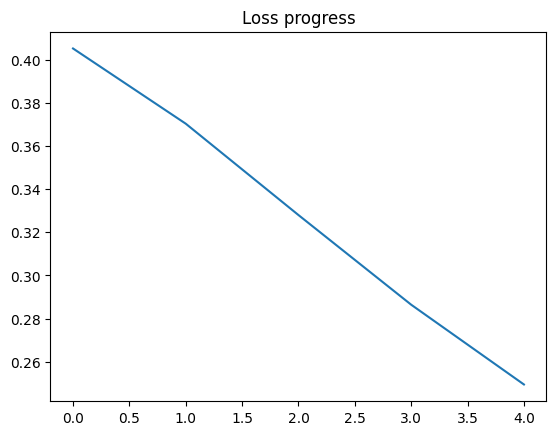

In [91]:
plt.plot(history.history["loss"])
plt.title("Loss progress");

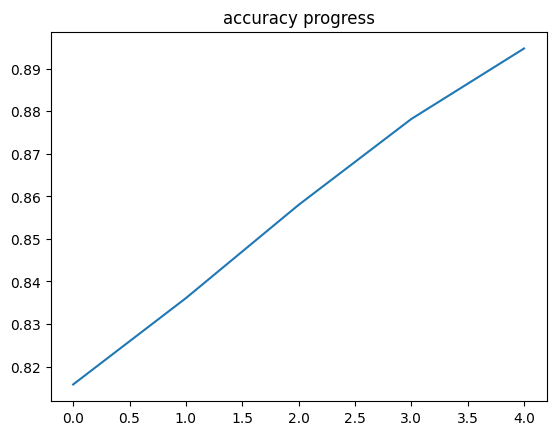

In [92]:
plt.plot(history.history["accuracy"])
plt.title("accuracy progress");

In [93]:
results = Dcnn.evaluate(test_dataset)
print(results)

4101/4101 ━━━━━━━━━━━━━━━━━━━━ 48s 11ms/step - accuracy: 0.8220 - loss: 0.4435
[0.44355273246765137, 0.8229014277458191]


/usr/local/lib/python3.12/dist-packages/keras/src/trainers/epoch_iterator.py:160: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()


In [94]:
def get_prediction(sentence):
  tokens = encode_sentence(sentence)
  inputs = tf.expand_dims(tokens, 0)

  output = Dcnn(inputs, training = False)
  sentiment = math.floor(output*2)

  if sentiment == 0:
    print("negative")
  elif sentiment == 1:
    print ("positive")

  print(sentiment)

In [95]:
get_prediction("This movie was pretty interesting")

positive
1


In [96]:
get_prediction("I'd rather not do that again ")

negative
0
